In [1]:

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from dataset_subset import make_cifar10_demo_subsets

In [2]:
SEED = 42
torch.manual_seed(SEED)

In [3]:

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


train_dataset = datasets.CIFAR10(
    root='data/',
    download=True,
    train=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='data/',
    download=True,
    train=False,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

50000
10000


In [5]:
USE_SMALL_SUBSET = True

if USE_SMALL_SUBSET:
    train_dataset, test_dataset = make_cifar10_demo_subsets(train_dataset, test_dataset, seed=SEED)


train_dataloader = DataLoader(
    dataset=train_dataset,
    shuffle=True,
    batch_size=64
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    shuffle=False,
    batch_size=64
)

In [6]:

images, labels = next(iter(test_dataloader))
print("images shape: ", images.shape)
print("labels shape: ", labels.shape)
print("first 10 labels: ", [CIFAR10_CLASSES[i] for i in labels[:10]])

images shape:  torch.Size([64, 3, 32, 32])
labels shape:  torch.Size([64])
first 10 labels:  ['dog', 'bird', 'horse', 'airplane', 'ship', 'truck', 'cat', 'cat', 'automobile', 'automobile']


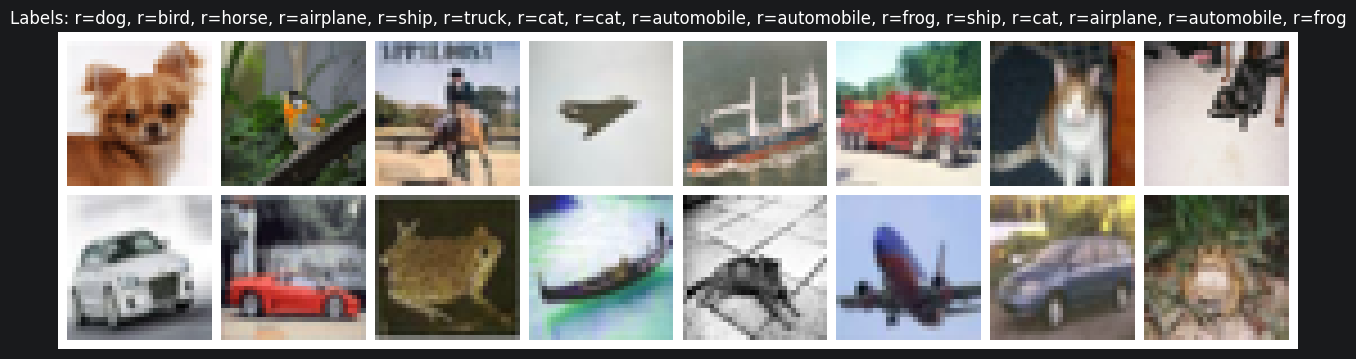

In [7]:

def denormalize_images(images, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    # mean, std.shape (3, )
    mean = torch.tensor(mean).view(1, 3, 1, 1)
    std = torch.tensor(std).view(1, 3, 1, 1)
    return torch.clamp(images.cpu() * std + mean, 0, 1)


def show_cifar10_sample(images, labels, n=16):
    grid = make_grid(denormalize_images(images[:n]), nrow=8, normalize=True, pad_value=1)

    plt.figure(figsize=(16, 6))
    plt.imshow(grid.permute(1, 2, 0))

    str_labels = [CIFAR10_CLASSES[i] for i in labels[:n]]

    title = ", ".join([f"r={n}" for n in str_labels])

    plt.title("Labels: " + title)
    plt.axis("off")

    plt.show()


show_cifar10_sample(images, labels, 16)

In [22]:

cifar_model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=5, padding=2),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=5, padding=2),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)

# функція помилок
loss_fn = nn.CrossEntropyLoss()

# оптимізатор
optimizer = optim.Adam(cifar_model.parameters(), lr=0.001)

Функція навчання

In [16]:
def train_one_epoch(model, dataloader, loss_fn, optimizer):
    model.train()

    total_loss = 0
    total_correct = 0
    total_items = 0

    for images, labels in dataloader:

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)

        loss = loss_fn(logits, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_items += labels.size(0)

    return {
        "loss": total_loss / total_items,
        "accuracy": total_correct / total_items
    }

Функція перевірки

In [17]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_items = 0

    for images, labels in dataloader:

        logits = model(images)

        loss = loss_fn(logits, labels)

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_items += labels.size(0)

    return {
        "loss": total_loss / total_items,
        "accuracy": total_correct / total_items
    }

Функція навчання всієї моделі

In [25]:
def model_fit(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs=10):
    history = []

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_dataloader, loss_fn, optimizer)

        test_metrics = evaluate(model, test_dataloader, loss_fn)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics['loss'],
            "train_accuracy": train_metrics['accuracy'] * 100,
            "test_loss": test_metrics['loss'],
            "test_accuracy": test_metrics['accuracy'] * 100
}
        history.append(row)
        print(row)

    return pd.DataFrame(history)

In [26]:
history = model_fit(
    cifar_model,
    train_dataloader,
    test_dataloader,
    loss_fn,
    optimizer,
    epochs=20
)

{'epoch': 1, 'train_loss': 1.3350481748580934, 'train_accuracy': 48.15, 'test_loss': 1.359840781211853, 'test_accuracy': 49.8}
{'epoch': 2, 'train_loss': 1.2775060968399048, 'train_accuracy': 50.2, 'test_loss': 1.358117739677429, 'test_accuracy': 51.4}
{'epoch': 3, 'train_loss': 1.2670315132141112, 'train_accuracy': 52.300000000000004, 'test_loss': 1.3549386863708497, 'test_accuracy': 48.4}
{'epoch': 4, 'train_loss': 1.2326507425308229, 'train_accuracy': 52.5, 'test_loss': 1.2906248559951783, 'test_accuracy': 54.400000000000006}
{'epoch': 5, 'train_loss': 1.1750145149230957, 'train_accuracy': 54.6, 'test_loss': 1.3151344623565673, 'test_accuracy': 54.6}
{'epoch': 6, 'train_loss': 1.1151176986694336, 'train_accuracy': 56.15, 'test_loss': 1.3215267658233643, 'test_accuracy': 53.400000000000006}
{'epoch': 7, 'train_loss': 1.1060841493606568, 'train_accuracy': 58.199999999999996, 'test_loss': 1.310115792274475, 'test_accuracy': 55.60000000000001}
{'epoch': 8, 'train_loss': 1.06528635883331

In [27]:
history

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,1.335048,48.15,1.359841,49.8
1,2,1.277506,50.20,1.358118,51.4
2,3,1.267032,52.30,1.354939,48.4
3,4,1.232651,52.50,1.290625,54.4
4,5,1.175015,54.60,1.315134,54.6
5,6,1.115118,56.15,1.321527,53.4
6,7,1.106084,58.20,1.310116,55.6
7,8,1.065286,58.55,1.356495,53.2
8,9,1.022859,59.90,1.471649,51.2
9,10,0.999218,60.00,1.279029,55.8
